Success cases exploration

Source: `output/success_cases/oracle_and_error_type_per_testcase_detected.csv`
1. Count of crash / behavioral per model and context variant
2. `llm_detected_errors` frequency, sorted descending

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

CSV_PATH = Path("output/success_cases/oracle_and_error_type_per_testcase_detected.csv")
df = pd.read_csv(CSV_PATH)
df["error_type"] = df["error_type"].fillna("n/a").replace("", "n/a")
print(df.shape)
df.head()

(3691, 20)


,context_variant,model,instance,test_file,test_case,num_assert_calls,oracle_methods_used,has_trycatch_assert,assert_calls,note,execution_result,llm_detected_errors,bump_bc_errors,matched_errors,missed_errors,new_errors,match_count,miss_count,new_count,error_type
0,Class,GPT4o,BBC03,BBC03U0Test.java,test_jsonSchemaFromTypeMirror,0,NaN,False,NaN,no explicit assertion in this test method,FAILURE,ClassNotFoundException|NoClassDefFoundError,ClassNotFoundException|MojoFailureException|No...,ClassNotFoundException|NoClassDefFoundError,MojoFailureException|RuntimeException,NaN,2,2,0,behavioral
1,Class,GPT4o,BBC06,BBC06U112Test.java,test_calculateMD5_emptyInput,1,assertEquals,False,"assertEquals(expectedMD5, actualMD5) [L28]",NaN,ERROR,NoClassDefFoundError,ClassNotFoundException|MojoFailureException|No...,NoClassDefFoundError,ClassNotFoundException|MojoFailureException,NaN,1,2,0,crash
2,Class,GPT4o,BBC06,BBC06U112Test.java,test_calculateMD5_largeInput,2,assertEquals|assertNotNull,False,assertNotNull(actualMD5) [L48] ;; assertEquals...,NaN,ERROR,NoClassDefFoundError,ClassNotFoundException|MojoFailureException|No...,NoClassDefFoundError,ClassNotFoundException|MojoFailureException,NaN,1,2,0,crash
3,Class,GPT4o,BBC06,BBC06U112Test.java,test_calculateMD5_nominal,1,assertEquals,False,"assertEquals(expectedMD5, actualMD5) [L18]",NaN,ERROR,NoClassDefFoundError,ClassNotFoundException|MojoFailureException|No...,NoClassDefFoundError,ClassNotFoundException|MojoFailureException,NaN,1,2,0,crash
4,Class,GPT4o,BBC06,BBC06U112Test.java,test_calculateMD5_nullInput,1,fail,True,"fail(msg=""Expected NullPointerException"") [L37]",NaN,ERROR,ClassNotFoundException|NoClassDefFoundError,ClassNotFoundException|MojoFailureException|No...,ClassNotFoundException|NoClassDefFoundError,MojoFailureException,NaN,2,1,0,crash


## 1. Crash vs. behavioral count, per model × context variant

In [2]:
stat1 = (
    df.groupby(["context_variant", "model", "error_type"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["behavioral", "crash", "n/a"], fill_value=0)
)
stat1["total"] = stat1.sum(axis=1)
stat1 = stat1.sort_values(["context_variant", "model"])
stat1

error_type                   behavioral  crash  n/a  total
context_variant model                                     
Class           GPT4o                15    422   24    461
                GPTOSS                7     92    2    101
                Qwen3-coder           9    867   12    888
Method          GPT4o                 0    384    5    389
                GPTOSS               10    107    0    117
                Qwen3-coder          52    729   75    856
Minimal         GPT4o                 2    169    1    172
                GPTOSS                0      9    0      9
                Qwen3-coder          81    611    6    698

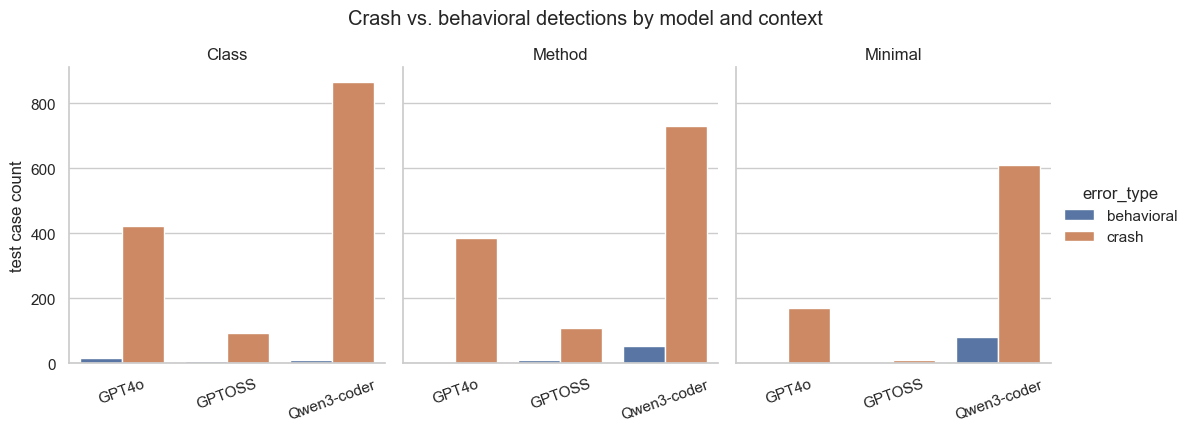

In [3]:
plot_df = (
    df[df["error_type"].isin(["behavioral", "crash"])]
    .groupby(["context_variant", "model", "error_type"])
    .size()
    .reset_index(name="count")
)

g = sns.catplot(
    data=plot_df, kind="bar",
    x="model", y="count", hue="error_type",
    col="context_variant",
    height=4, aspect=0.9,
    palette={"behavioral": "#4C72B0", "crash": "#DD8452"},
)
g.set_axis_labels("", "test case count")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=20)
g.figure.suptitle("Crash vs. behavioral detections by model and context", y=1.05)
plt.show()

### Same, as a share of each model/context's total (log-scale skew makes raw counts hard to compare)

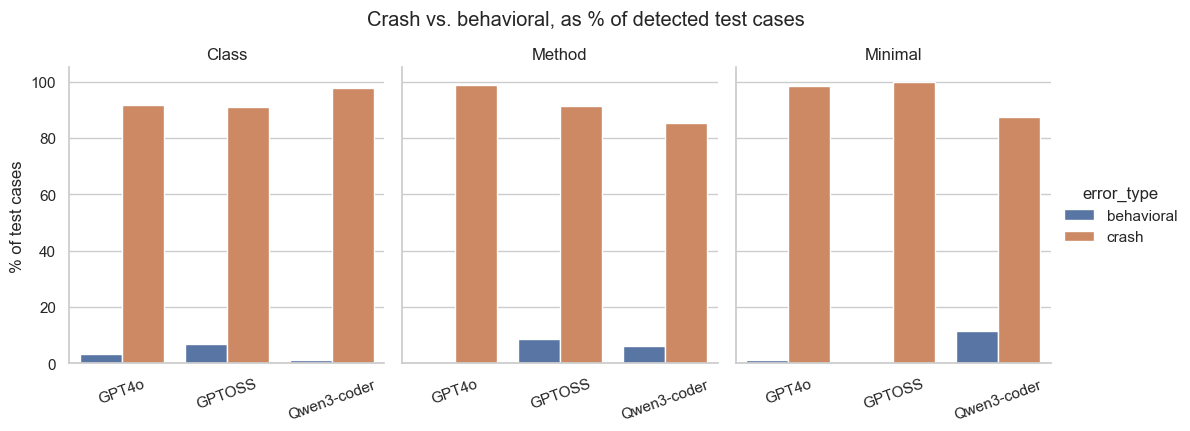

In [4]:
share = stat1[["behavioral", "crash"]].div(stat1["total"], axis=0) * 100
share = share.reset_index()
share_melt = share.melt(id_vars=["context_variant", "model"], var_name="error_type", value_name="pct")

g = sns.catplot(
    data=share_melt, kind="bar",
    x="model", y="pct", hue="error_type",
    col="context_variant",
    height=4, aspect=0.9,
    palette={"behavioral": "#4C72B0", "crash": "#DD8452"},
)
g.set_axis_labels("", "% of test cases")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=20)
g.figure.suptitle("Crash vs. behavioral, as % of detected test cases", y=1.05)
plt.show()

## 2. `llm_detected_errors` frequency, sorted descending

`llm_detected_errors` is a pipe-separated set of exception class names per test case; explode it so each
(test case, exception) pair is its own row, then count how often each exception type appears.

In [5]:
errors_exploded = (
    df.assign(llm_detected_errors=df["llm_detected_errors"].fillna("").str.split("|"))
    .explode("llm_detected_errors")
)
errors_exploded = errors_exploded[errors_exploded["llm_detected_errors"] != ""]

error_counts = (
    errors_exploded["llm_detected_errors"]
    .value_counts()
    .rename_axis("llm_detected_error")
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
error_counts

,llm_detected_error,count
0,NoClassDefFoundError,2556
1,NoSuchMethodError,985
2,ClassNotFoundException,971
3,AssertionFailedError,163
4,InvocationTargetException,12
5,AssertionError,5
6,IllegalArgumentException,3


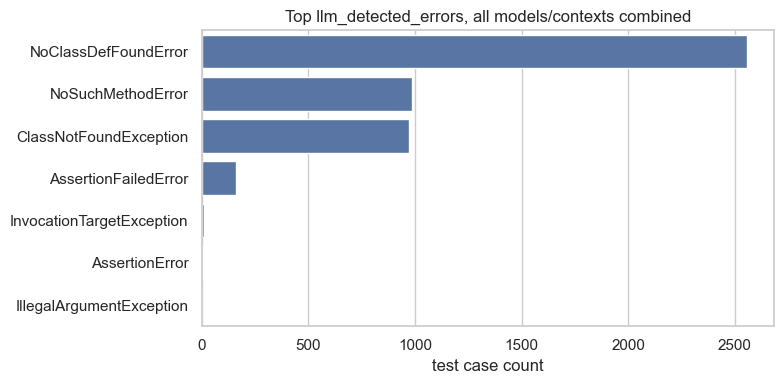

In [6]:
top_n = error_counts.head(20)

plt.figure(figsize=(8, max(4, 0.35 * len(top_n))))
sns.barplot(data=top_n, y="llm_detected_error", x="count", color="#4C72B0")
plt.xlabel("test case count")
plt.ylabel("")
plt.title("Top llm_detected_errors, all models/contexts combined")
plt.tight_layout()
plt.show()

### Same, broken down by model (top 10 errors per model)

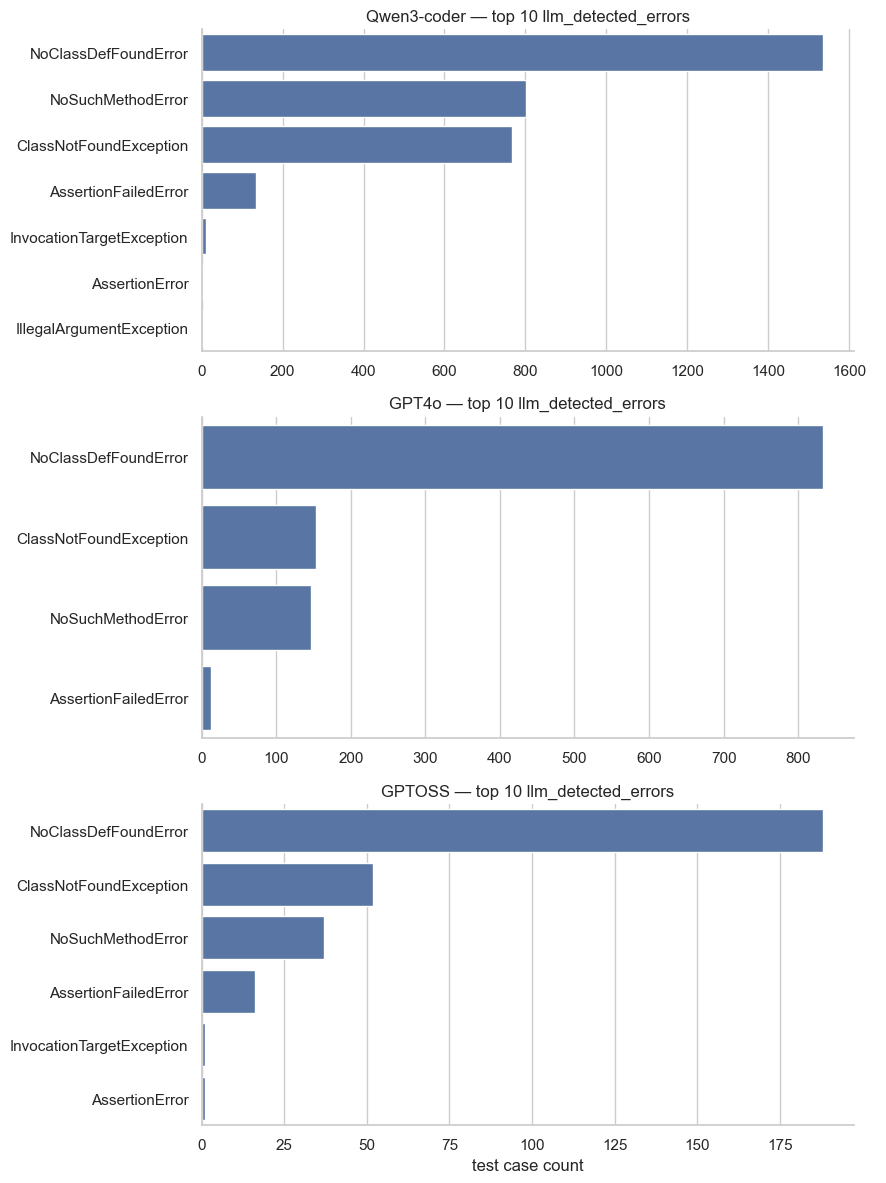

In [7]:
by_model = (
    errors_exploded.groupby(["model", "llm_detected_errors"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top10_per_model = by_model.groupby("model").head(10)

g = sns.catplot(
    data=top10_per_model, kind="bar",
    y="llm_detected_errors", x="count",
    col="model", col_wrap=1,
    height=4, aspect=2.2,
    color="#4C72B0", sharex=False, sharey=False,
)
g.set_axis_labels("test case count", "")
g.set_titles("{col_name} — top 10 llm_detected_errors")
plt.tight_layout()
plt.show()

Based on paper by Jayasurya and BUMP.

In [1]:
import pandas as pd
df = pd.read_csv(OUTPUT_CSV := "output/success_cases/oracle_type_per_testcase_failure_captured.csv")

# 0. sanity: this table is already the detecting-test-case set
assert set(df.execution_result.unique()) <= {"FAILURE", "ERROR"}
print(f"{len(df)} detecting test cases over {df.instance.nunique()} instances, "
      f"{df.groupby(['context_variant','model']).ngroups} model×context cells")

# 1. mechanism from Surefire (authoritative, no guessing)
df["mechanism"] = df.execution_result.map({"FAILURE": "assertion", "ERROR": "crash"})

# 2. RAW LANDSCAPE — look before you bucket. Nothing is decided yet.
print("\n-- root_cause frequency (crash rows) --")
print(df.loc[df.mechanism=="crash", "root_cause"].value_counts(dropna=False))
print("\n-- root_cause_source (crash rows) --")   # 'none'/'wrapper' = inspect these
print(df.loc[df.mechanism=="crash", "root_cause_source"].value_counts())

3566 detecting test cases over 27 instances, 9 model×context cells

-- root_cause frequency (crash rows) --
root_cause
NoClassDefFoundError      1441
NoSuchMethodError          984
ClassNotFoundException     965
Name: count, dtype: int64

-- root_cause_source (crash rows) --
root_cause_source
top          2419
caused_by     971
Name: count, dtype: int64


In [2]:
# 3. Coarse family map. Edit freely. Anything NOT listed is reported below,
#    not silently dropped — that's the guardrail against missing a type.
FAMILY = {
    "linkage": {"NoClassDefFoundError","NoSuchMethodError","NoSuchFieldError",
                "ClassNotFoundException","LinkageError","ExceptionInInitializerError",
                "IncompatibleClassChangeError","AbstractMethodError",
                "UnsupportedClassVersionError"},
    # add runtime types you actually observe from the value_counts above:
    "runtime": {"NullPointerException","IllegalStateException","IllegalArgumentException",
                "ClassCastException","IndexOutOfBoundsException","NumberFormatException",
                "UnsupportedOperationException"},
}
lookup = {exc: fam for fam, s in FAMILY.items() for exc in s}

def family(row):
    if row.mechanism == "assertion":
        return "assertion"
    return lookup.get(row.root_cause, "UNMAPPED::" + (row.root_cause or "EMPTY"))

df["family"] = df.apply(family, axis=1)

# 4. AUDIT — did the map miss anything? These are the ones to eyeball and file.
unmapped = df.loc[df.family.str.startswith("UNMAPPED"), "root_cause"].value_counts()
if len(unmapped):
    print("UNMAPPED root causes (decide a family for each):")
    print(unmapped)
else:
    print("All crash root-causes mapped.")

All crash root-causes mapped.


In [3]:
def dual(frame, by):
    return (frame.groupby(by)
                 .agg(n_cases=("test_case","size"),
                      n_instances=("instance","nunique"))
                 .reset_index())

# headline: mechanism/family mix per model × context
cut1 = dual(df, ["context_variant","model","family"])

# crash drill-down: exact exceptions
cut2 = dual(df[df.mechanism=="crash"], ["context_variant","model","root_cause"])

# assertion drill-down: which oracles catch breaks (+ value vs expected-exception)
df["assert_kind"] = df.apply(
    lambda r: "expected_exception" if r.has_trycatch_assert else "value_assertion", axis=1)
cut3 = dual(df[df.mechanism=="assertion"], ["context_variant","model","assert_kind"])

# reflection context (explains a high linkage share if present)
refl = df.groupby(["context_variant","model"]).reflective.mean().round(2)

In [4]:
from IPython.display import display
display(cut1)
display(cut2)
print(unmapped)                      # from the audit cell
print(df.loc[df.mechanism=="crash", "root_cause"].value_counts(dropna=False))

,context_variant,model,family,n_cases,n_instances
0,Class,GPT4o,assertion,15,9
1,Class,GPT4o,linkage,422,14
2,Class,GPTOSS,assertion,7,2
3,Class,GPTOSS,linkage,92,9
4,Class,Qwen3-coder,assertion,9,6
5,Class,Qwen3-coder,linkage,867,13
6,Method,GPT4o,linkage,384,11
7,Method,GPTOSS,assertion,10,3
8,Method,GPTOSS,linkage,107,8
9,Method,Qwen3-coder,assertion,52,7


,context_variant,model,root_cause,n_cases,n_instances
0,Class,GPT4o,ClassNotFoundException,55,8
1,Class,GPT4o,NoClassDefFoundError,323,11
2,Class,GPT4o,NoSuchMethodError,44,3
3,Class,GPTOSS,ClassNotFoundException,24,4
4,Class,GPTOSS,NoClassDefFoundError,57,8
5,Class,GPTOSS,NoSuchMethodError,11,3
6,Class,Qwen3-coder,ClassNotFoundException,303,7
7,Class,Qwen3-coder,NoClassDefFoundError,269,11
8,Class,Qwen3-coder,NoSuchMethodError,295,3
9,Method,GPT4o,ClassNotFoundException,57,5


Series([], Name: count, dtype: int64)
root_cause
NoClassDefFoundError      1441
NoSuchMethodError          984
ClassNotFoundException     965
Name: count, dtype: int64


In [5]:
print(df.loc[df.mechanism=="crash","root_cause"].value_counts(dropna=False))
print(df.loc[df.family.str.startswith("UNMAPPED"),"root_cause"].value_counts())
print(df.groupby(["context_variant","model"]).reflective.mean().round(2))

root_cause
NoClassDefFoundError      1441
NoSuchMethodError          984
ClassNotFoundException     965
Name: count, dtype: int64
Series([], Name: count, dtype: int64)
context_variant  model      
Class            GPT4o          0.00
                 GPTOSS         0.00
                 Qwen3-coder    0.01
Method           GPT4o          0.00
                 GPTOSS         0.01
                 Qwen3-coder    0.01
Minimal          GPT4o          0.00
                 GPTOSS         0.00
                 Qwen3-coder    0.00
Name: reflective, dtype: float64


In [6]:
asrt = df[df.mechanism == "assertion"].copy()   # the 176 FAILURE rows

def oracle_intent(o):
    o = str(o)
    if "assertDoesNotThrow" in o:                 return "does_not_throw (crash guard)"
    if o in ("", "nan"):                          return "no_explicit_assert"
    if "fail" in o and ("assertNotNull" in o):    return "existence_probe"
    return "value_assertion"

asrt["oracle_intent"] = asrt.oracle_methods_used.apply(oracle_intent)

print(asrt.oracle_intent.value_counts())                       # the 3 numbers for part 3
print(asrt.groupby("model").oracle_intent.value_counts())      # who writes value oracles
# behavioral (value) detections at instance level, so verbosity doesn't inflate:
print(asrt[asrt.oracle_intent=="value_assertion"]
        .groupby(["model","context_variant"]).instance.nunique())

oracle_intent
does_not_throw (crash guard)    136
value_assertion                  25
no_explicit_assert                8
existence_probe                   7
Name: count, dtype: int64
model        oracle_intent               
GPT4o        value_assertion                  13
             no_explicit_assert                4
GPTOSS       does_not_throw (crash guard)     12
             no_explicit_assert                4
             value_assertion                   1
Qwen3-coder  does_not_throw (crash guard)    124
             value_assertion                  11
             existence_probe                   7
Name: count, dtype: int64
model        context_variant
GPT4o        Class              7
GPTOSS       Method             1
Qwen3-coder  Class              3
             Method             5
             Minimal            2
Name: instance, dtype: int64


In [7]:
print(df[df.mechanism=="crash"].instance.nunique())       # -> [?B]
print(df[df.mechanism=="assertion"].instance.nunique())   # -> [?C]

17
16


In [9]:
# crash instances per model × context
df[df.mechanism=="crash"].groupby(["context_variant","model"]).instance.nunique()



context_variant  model      
Class            GPT4o          14
                 GPTOSS          9
                 Qwen3-coder    13
Method           GPT4o          11
                 GPTOSS          8
                 Qwen3-coder    13
Minimal          GPT4o          13
                 GPTOSS          3
                 Qwen3-coder    10
Name: instance, dtype: int64

In [10]:
# assertion instances per model × context
df[df.mechanism=="assertion"].groupby(["context_variant","model"]).instance.nunique()

context_variant  model      
Class            GPT4o          9
                 GPTOSS         2
                 Qwen3-coder    6
Method           GPTOSS         3
                 Qwen3-coder    7
Minimal          GPT4o          2
                 Qwen3-coder    7
Name: instance, dtype: int64

In [13]:
df["mechanism"] = df.execution_result.map({"FAILURE": "assertion", "ERROR": "crash"})

In [14]:
df[df.execution_result=="FAILURE"].root_cause.value_counts(dropna=False)

root_cause
NoClassDefFoundError      142
AssertionFailedError       23
ClassNotFoundException      6
AssertionError              5
Name: count, dtype: int64

In [15]:
a = df[df.execution_result=="FAILURE"]
# rows where the mechanism is an assertion but the cause is linkage:
a[a.root_cause.isin(["NoClassDefFoundError","ClassNotFoundException"])][
    ["oracle_methods_used","llm_detected_errors","root_cause","root_cause_source"]
].head(20)

,oracle_methods_used,llm_detected_errors,root_cause,root_cause_source
0,NaN,ClassNotFoundException|NoClassDefFoundError,ClassNotFoundException,caused_by
214,NaN,ClassNotFoundException|NoClassDefFoundError,ClassNotFoundException,caused_by
509,NaN,AssertionFailedError|NoClassDefFoundError,NoClassDefFoundError,caused_by
510,NaN,AssertionFailedError|NoClassDefFoundError,NoClassDefFoundError,caused_by
513,NaN,AssertionFailedError|NoClassDefFoundError,NoClassDefFoundError,caused_by
514,NaN,AssertionFailedError|NoClassDefFoundError,NoClassDefFoundError,caused_by
515,assertDoesNotThrow|assertNotNull,AssertionFailedError|NoClassDefFoundError,NoClassDefFoundError,caused_by
517,assertDoesNotThrow|assertTrue,AssertionFailedError|NoClassDefFoundError,NoClassDefFoundError,caused_by
528,assertDoesNotThrow,AssertionFailedError|NoClassDefFoundError,NoClassDefFoundError,caused_by
1289,assertNotNull|assertTrue,ClassNotFoundException|NoClassDefFoundError,ClassNotFoundException,caused_by


In [16]:
a = df[df.execution_result=="FAILURE"].copy()

def assert_type(row):
    toks = set(str(row.llm_detected_errors).split("|"))
    if "AssertionFailedError" in toks: return "AssertionFailedError"
    if "AssertionError" in toks:       return "AssertionError"
    # rows where the union shows only the linkage error (source=caused_by/top,
    # no assertion token) — Surefire still reported FAILURE, so JUnit raised an
    # assertion error that the extractor didn't surface; inspect these:
    return "UNRESOLVED"

a["assert_type"] = a.apply(assert_type, axis=1)
print(a.assert_type.value_counts())

assert_type
AssertionFailedError    163
UNRESOLVED                8
AssertionError            5
Name: count, dtype: int64


In [17]:
c = df[df.execution_result=="ERROR"]
for rc in ["NoClassDefFoundError","NoSuchMethodError","ClassNotFoundException"]:
    toks = (c[c.root_cause==rc].llm_detected_errors
              .str.split("|").explode())
    toks = toks[toks != rc]                       # drop the root itself
    print(rc, toks.value_counts().to_dict())

NoClassDefFoundError {'InvocationTargetException': 2}
NoSuchMethodError {'InvocationTargetException': 4, 'IllegalArgumentException': 2}
ClassNotFoundException {'NoClassDefFoundError': 965, 'InvocationTargetException': 6, 'IllegalArgumentException': 1}


In [18]:
c = df[df.execution_result=="ERROR"]
crash_tokens = c.llm_detected_errors.str.split("|").explode()
print(crash_tokens.value_counts())

llm_detected_errors
NoClassDefFoundError         2406
NoSuchMethodError             984
ClassNotFoundException        965
InvocationTargetException      12
IllegalArgumentException        3
Name: count, dtype: int64


In [19]:
a = df[(df.execution_result=="FAILURE") &
       (df.oracle_methods_used.str.contains("assertDoesNotThrow", na=False))]
print(a[["context_variant","model","instance","test_file","test_case","root_cause"]]
      .sort_values("root_cause").to_string())

     context_variant        model instance           test_file                       test_case            root_cause
515            Class       GPTOSS    BBC72  BBC72U449Test.java                       test_main  NoClassDefFoundError
3502         Minimal  Qwen3-coder    BBC73  BBC73U237Test.java                       test_main  NoClassDefFoundError
3501         Minimal  Qwen3-coder    BBC73  BBC73U234Test.java                       test_main  NoClassDefFoundError
3499         Minimal  Qwen3-coder    BBC73  BBC73U224Test.java                       test_main  NoClassDefFoundError
3475         Minimal  Qwen3-coder    BBC72   BBC72U54Test.java                       test_main  NoClassDefFoundError
3474         Minimal  Qwen3-coder    BBC72   BBC72U53Test.java                       test_main  NoClassDefFoundError
3473         Minimal  Qwen3-coder    BBC72  BBC72U539Test.java                       test_main  NoClassDefFoundError
3472         Minimal  Qwen3-coder    BBC72  BBC72U523Test.java  

NameError: name 'show_block' is not defined